# Paper Plots

Assemble the paper's figures and tables from the scripts in
`paper-results/figures/`, `paper-results/compute_fwi_results.py`, and `paper-results/latex_tables.py` 


## 0. Setup

In [1]:
%matplotlib inline
import sys, os

PAPER_DIR = os.path.abspath(".")
sys.path.insert(0, PAPER_DIR)
sys.path.insert(0, os.path.join(PAPER_DIR, "figures"))
print(f"PAPER_DIR = {PAPER_DIR}")

PRECOMPUTED_DIR = os.path.join(PAPER_DIR, "precomputed")

import pandas as pd
from IPython.display import display
import latex_tables as lt

PAPER_DIR = /cluster/home/fscharitzer/semester-project/diffusion-fwi-2d-clean/paper-results


---
## 1. Acquisition setup

/cluster/home/fscharitzer/semester-project/diffusion-fwi-2d-clean/paper-results/figures/fig1_setup.py:246: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved: /cluster/home/fscharitzer/semester-project/diffusion-fwi-2d-clean/paper-results/results/figures/fig1_setup_panel.pdf
  Saved: /cluster/home/fscharitzer/semester-project/diffusion-fwi-2d-clean/paper-results/results/figures/fig1_setup_panel.svg
  transducer index: 0. Panel C shows shot_id='0' — by default this is str(active_idx), which assumes the acquisition's shot numbering matches the geometry ring's ordering. Verify that holds for your data, or pass shot_id explicitly if it doesn't.


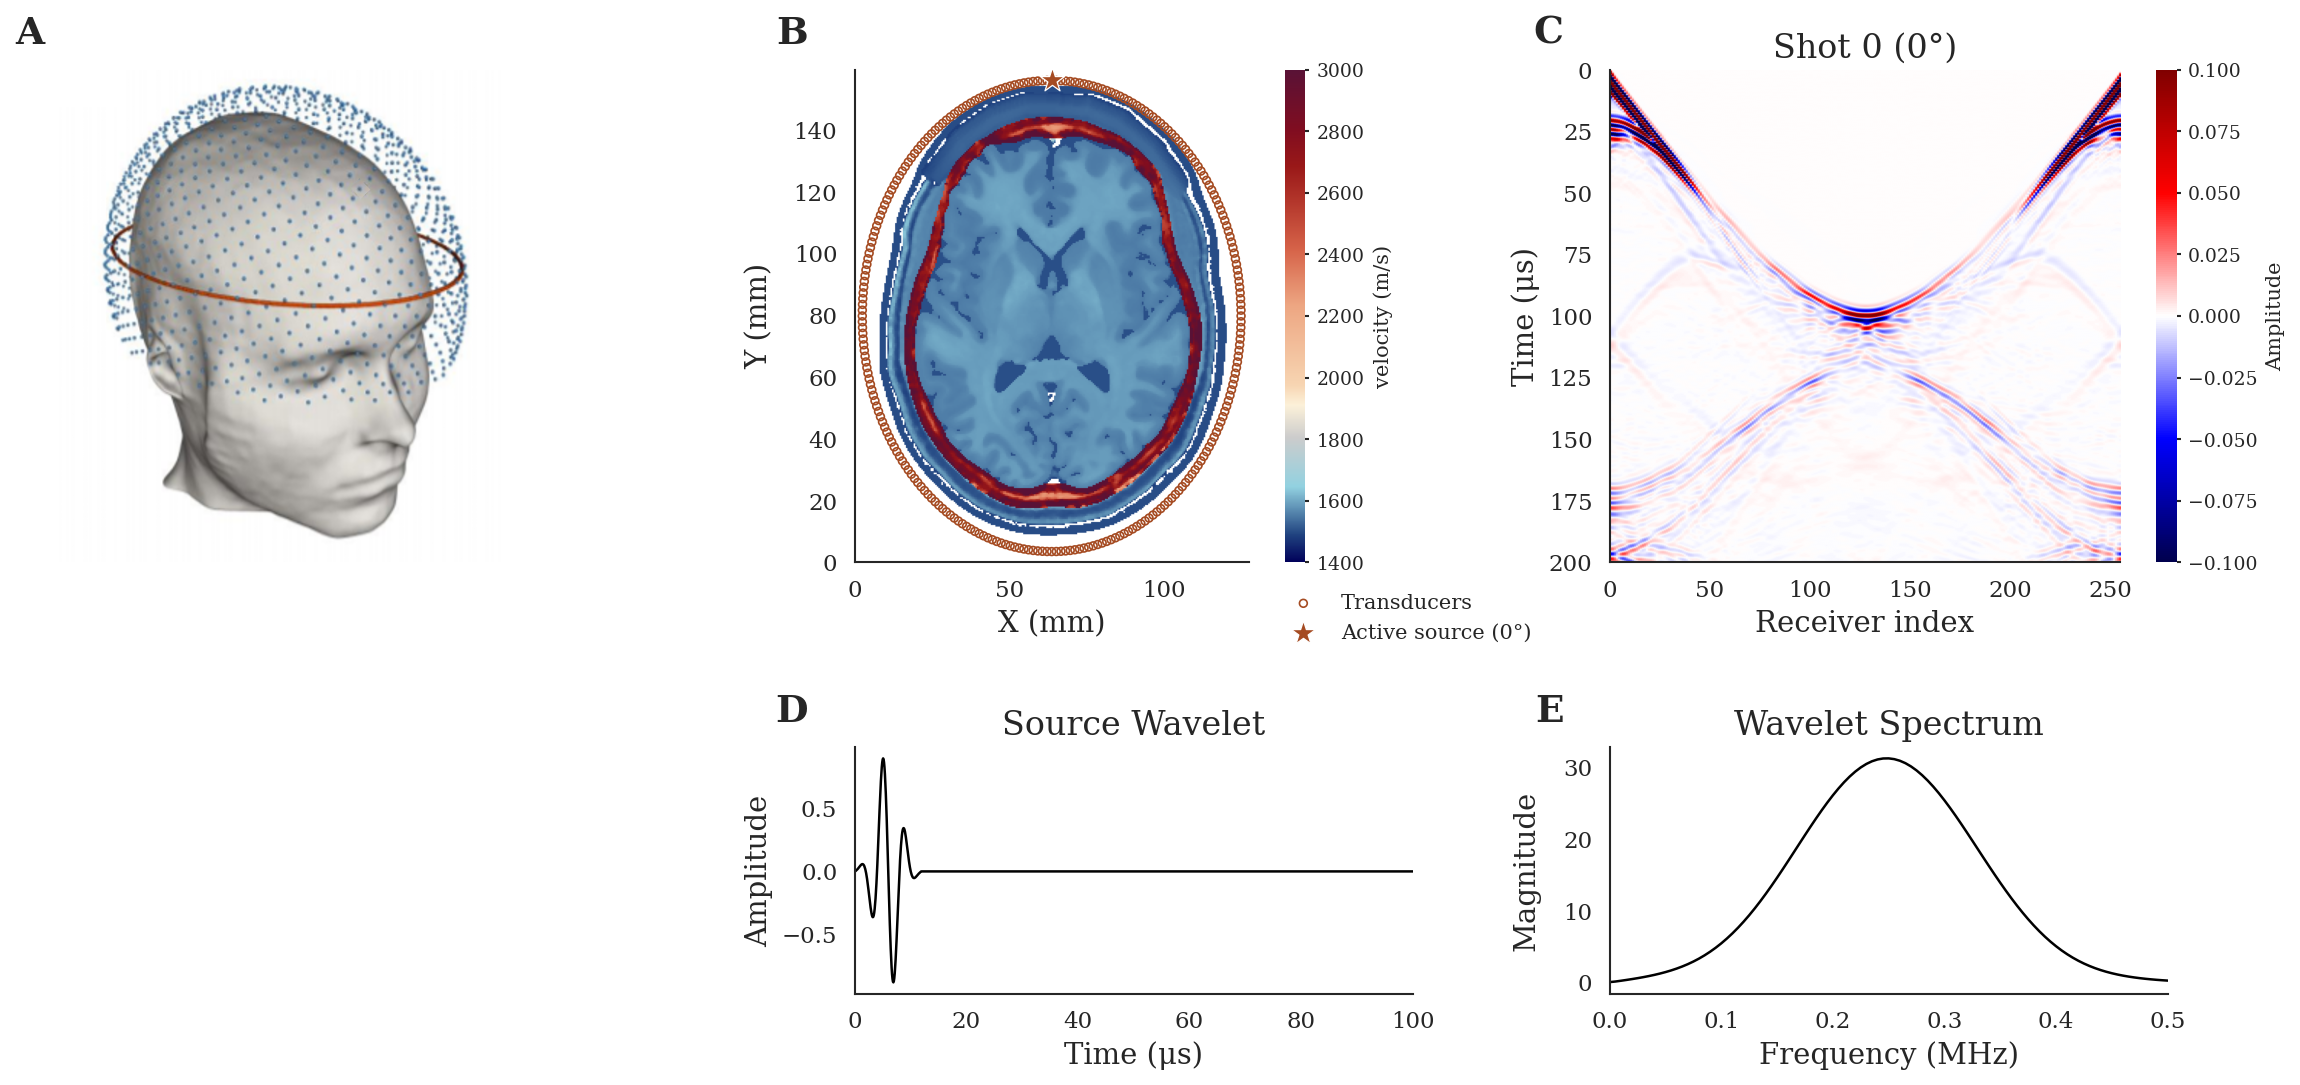

In [2]:
import fig1_setup

# Uses stored brain GT velocity map and one shot acquisition data
# Ring geometry is pre-computed to avoid dependence on stride environment setup 

fig1, axs1, active_idx = fig1_setup.plot_setup_figure_groundtruth(
    brain_id="654754",
    gt_dir=os.path.join(PAPER_DIR, "data", "fig1"),
    forward_dir=os.path.join(PAPER_DIR, "data", "fig1"),
    save_dir=os.path.join(PAPER_DIR, "results", "figures"),
    formats=("pdf", "svg"),
    show=False,
    precomputed_ring_geometry=os.path.join(PAPER_DIR, "data", "fig1", "ring_geometry.npz"),
)


---
## 2. Table: Diffusion model ablation

In [3]:
TABLE2_CAPTION = '\\textbf{Diffusion model sample quality and ablation study.} All values reported as mean $\\pm$ std across $N=10$ independently trained models (different random seeds). FID-In/FID-Rad: distance to ImageNet/RadImageNet features~\\cite{heusel2017gans,mei2022radimagenet}, LPIPS: perceptual diversity~\\cite{zhang2018unreasonable}, $\\Delta\\mu$/$\\Delta\\mathrm{std}$: relative deviation of generated ST/SK velocity mean/std from reference. \\textit{Real$\\leftrightarrow$Real}/\\textit{Blurred} and \\textit{Aug.$\\leftrightarrow$Aug.}/\\textit{Blurred} give lower/upper bounds for the clean and augmented reference distributions. Bold/underline: best/second-best in each block.'

DIFFUSION_OUTPUT_DIR = os.path.join(PAPER_DIR, "results")
os.makedirs(DIFFUSION_OUTPUT_DIR, exist_ok=True)

lt.write_diffusion_ablation_latex_table(
    base_dir=None,
    output_tex=os.path.join(DIFFUSION_OUTPUT_DIR, "table2_diffusion_ablation.tex"),
    caption=TABLE2_CAPTION,
    precomputed_json=os.path.join(PRECOMPUTED_DIR, "table2_diffusion_ablation.json"),
)
print(open(os.path.join(DIFFUSION_OUTPUT_DIR, "table2_diffusion_ablation.tex")).read())

Saved: /cluster/home/fscharitzer/semester-project/diffusion-fwi-2d-clean/paper-results/results/table2_diffusion_ablation.tex
\begin{table*}[htbp]
\centering
\caption{\textbf{Diffusion model sample quality and ablation study.} All values reported as mean $\pm$ std across $N=10$ independently trained models (different random seeds). FID-In/FID-Rad: distance to ImageNet/RadImageNet features~\cite{heusel2017gans,mei2022radimagenet}, LPIPS: perceptual diversity~\cite{zhang2018unreasonable}, $\Delta\mu$/$\Delta\mathrm{std}$: relative deviation of generated ST/SK velocity mean/std from reference. \textit{Real$\leftrightarrow$Real}/\textit{Blurred} and \textit{Aug.$\leftrightarrow$Aug.}/\textit{Blurred} give lower/upper bounds for the clean and augmented reference distributions. Bold/underline: best/second-best in each block.}
\label{tab:diffusion_metrics}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lccccccc}
\toprule
Model & FID-In $\downarrow$ & FID-Rad $\downarrow$ & LPIPS $\uparrow$ & ST $

---
## 3. Figure: Diffusion model sample quality

  Saved: /cluster/home/fscharitzer/semester-project/diffusion-fwi-2d-clean/paper-results/results/figures/fig3_samples.pdf
  Saved: /cluster/home/fscharitzer/semester-project/diffusion-fwi-2d-clean/paper-results/results/figures/fig3_samples.svg


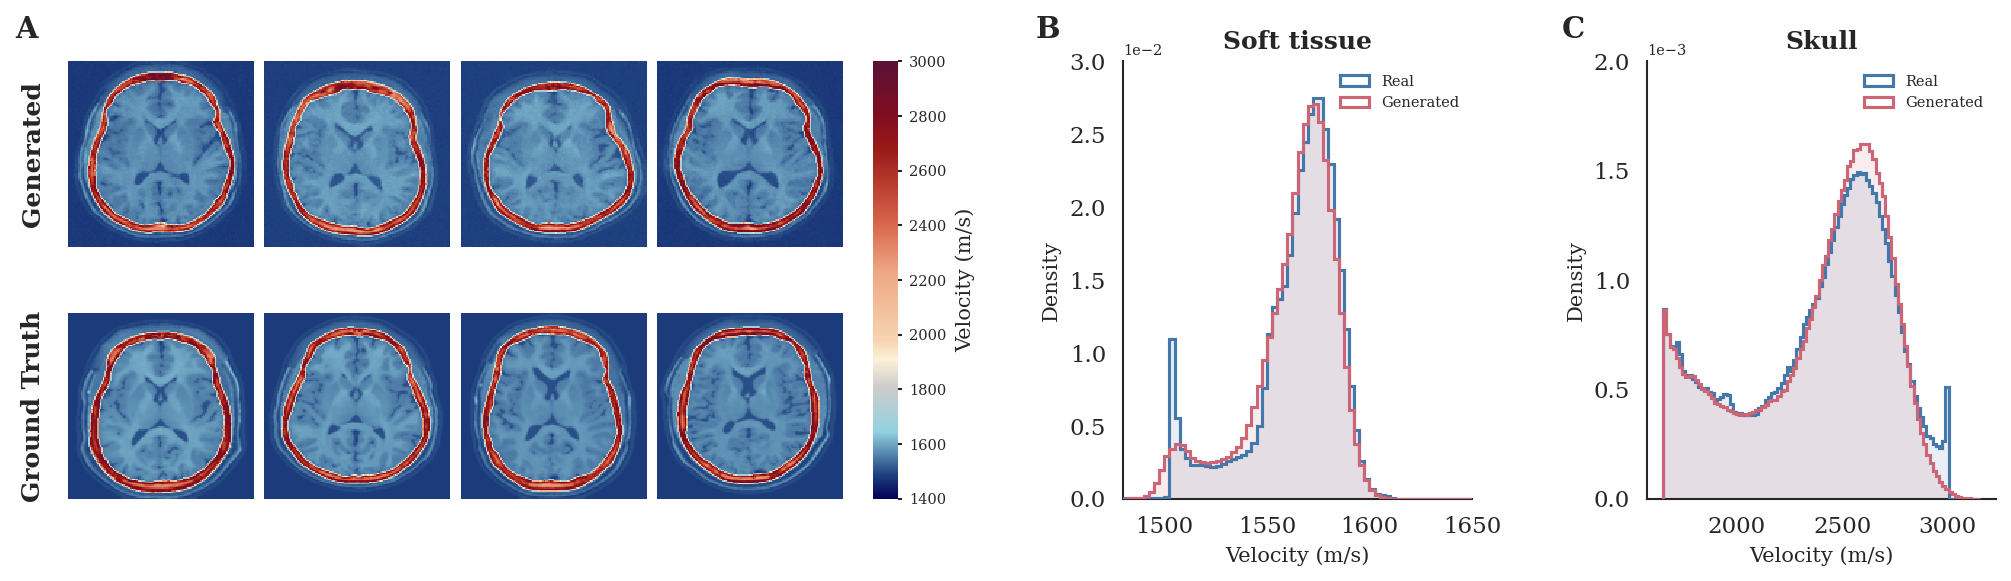

In [4]:
import fig3_samples

fig3, brain_axes, hist_axes = fig3_samples.main(
    show=True,
    precomputed_histogram_dir=os.path.join(PAPER_DIR, "data", "fig3"),
)

---
## 4. Figure: Hyperparameter sweep


Saved: /cluster/home/fscharitzer/semester-project/diffusion-fwi-2d-clean/paper-results/results/figures/fig4_hyperparameter_sweep.pdf


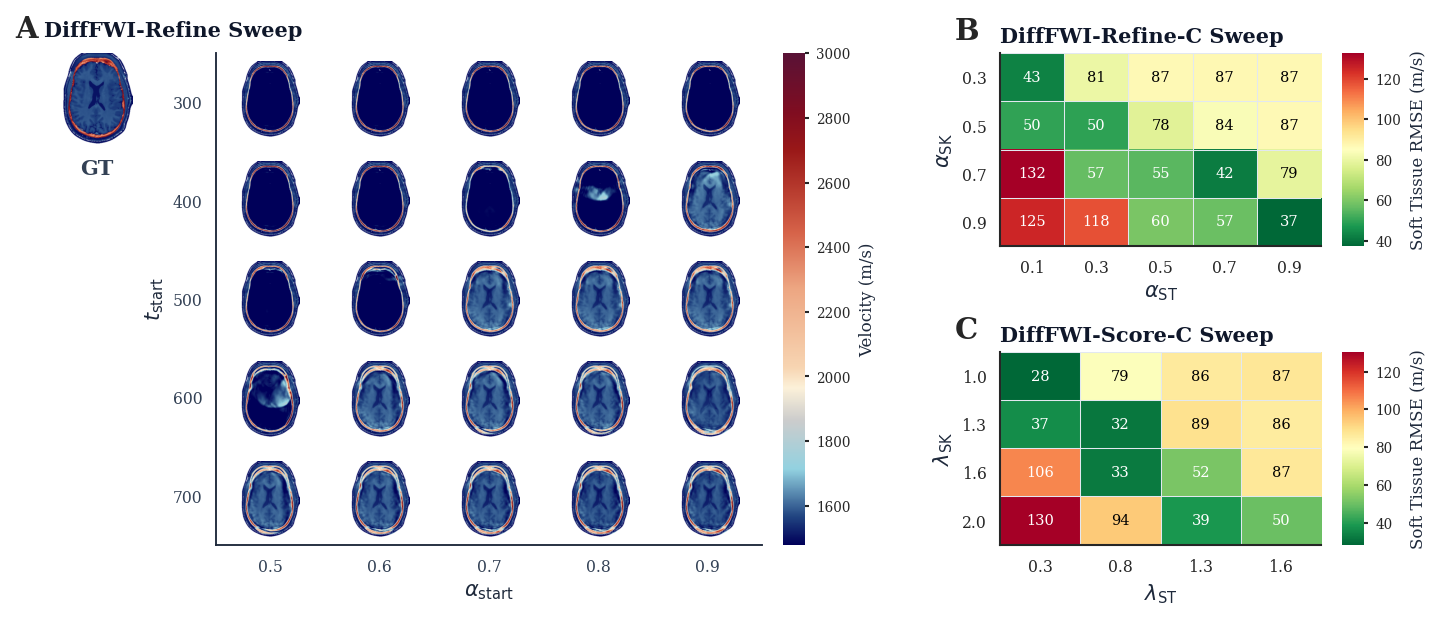

In [5]:
import fig4_sweep

fig4 = fig4_sweep.main(
    precomputed_matrices_json=os.path.join(PAPER_DIR, "data", "fig4", "fig4_sweep_matrices.json"),
    precomputed_sweep_root=os.path.join(PAPER_DIR, "data", "fig4", "sweep_root"),
    precomputed_gt_dir=os.path.join(PAPER_DIR, "data", "fig4"),
)

---
## 5. Table: Main FWI reconstruction performance (reference prior)


In [6]:
REFERENCE_OUTPUT_DIR = os.path.join(PAPER_DIR, "results", "reference")  # regenerable output only
TABLE3_CAPTION = '\\textbf{FWI reconstruction performance across acquisition settings.} Convergence rate, ST-RMSE, MS-SSIM and PSNR reported as mean $\\pm$ std, $N\\!=\\!197$. Scenarios and guidance methods (DG, DG-C, SG, SG-C) as defined in \\Cref{tab:scenarios} and \\Cref{sec:coupling}. Bold/underline: best/second-best within each scenario block.'

summary_main = pd.read_csv(os.path.join(PRECOMPUTED_DIR, "summary_main.csv"))
display(summary_main)

os.makedirs(REFERENCE_OUTPUT_DIR, exist_ok=True)
lt.write_fwi_latex_table(
    os.path.join(PRECOMPUTED_DIR, "summary_main.csv"),
    os.path.join(REFERENCE_OUTPUT_DIR, "table3_fwi_results.tex"),
    caption=TABLE3_CAPTION,
    label="tab:fwi_consolidated_metrics",
)

,scenario,method,convergence_rate_pct,tissue_rmse_mean_all,tissue_rmse_std_all,ms_ssim_mean_all,ms_ssim_std_all,psnr_mean_all,psnr_std_all
0,standard,baseline,37.6,59.3,33.9,0.9239,0.0361,20.15,2.30
1,standard,dg,82.7,25.0,10.3,0.9472,0.0259,21.59,1.78
2,standard,dg_c,91.4,22.9,9.7,0.9518,0.0208,21.86,1.54
3,standard,sg,95.4,17.8,8.4,0.9697,0.0202,23.60,1.54
4,standard,sg_c,98.0,17.0,6.8,0.9755,0.0148,24.23,1.17
5,reduced_compute,baseline,0.5,87.4,6.0,0.8942,0.0188,17.95,1.16
6,reduced_compute,dg,38.1,51.4,23.7,0.9124,0.0301,19.14,2.13
7,reduced_compute,dg_c,71.6,33.0,14.2,0.9341,0.0265,20.71,1.70
8,reduced_compute,sg,84.3,23.1,11.6,0.9504,0.0273,22.01,1.83
9,reduced_compute,sg_c,92.9,21.8,9.8,0.9626,0.0216,23.31,1.52


Saved: /cluster/home/fscharitzer/semester-project/diffusion-fwi-2d-clean/paper-results/results/reference/table3_fwi_results.tex


---
## 6. Table: Reconstruction quality conditional on convergence


In [7]:
TABLE_B2_CAPTION = '\\textbf{Reconstruction quality conditional on convergence.} ST-RMSE, MS-SSIM, and PSNR (mean $\\pm$ std) for the $N\\!=\\!26$ test brains in the Standard setting converging under all five methods, isolating quality from convergence rate. Bold/underline: best/second-best.'

summary_appendix = pd.read_csv(os.path.join(PRECOMPUTED_DIR, "summary_appendix_common.csv"))
display(summary_appendix)

lt.write_common_converged_latex_table(
    os.path.join(PRECOMPUTED_DIR, "summary_appendix_common.csv"),
    os.path.join(REFERENCE_OUTPUT_DIR, "tableB2_common_converged.tex"),
    caption=TABLE_B2_CAPTION,
    label="tab:fwi_common_converged_metrics",
)

,method,n_common,tissue_rmse_mean,tissue_rmse_std,ms_ssim_mean,ms_ssim_std,psnr_mean,psnr_std
0,baseline,26,17.4,5.6,0.9618,0.0107,22.82,1.01
1,dg,26,17.7,2.3,0.9664,0.0059,23.15,0.80
2,dg_c,26,16.9,2.5,0.9663,0.0055,23.10,0.81
3,sg,26,14.7,3.5,0.9782,0.0054,24.50,0.87
4,sg_c,26,15.0,1.5,0.9820,0.0027,25.00,0.71


Saved: /cluster/home/fscharitzer/semester-project/diffusion-fwi-2d-clean/paper-results/results/reference/tableB2_common_converged.tex


---
## 7. Figure: Convergence criterion across acquisition scenarios

*Note: at the time of writing, the `dg_c` method has fewer completed FWI seeds
than the other methods (a known batch of runs is still being re-run to full
coverage). This figure should be regenerated once those runs finish.*


  Saved: /cluster/home/fscharitzer/semester-project/diffusion-fwi-2d-clean/paper-results/results/figures/fig5_convergence_metric.pdf
  Saved: /cluster/home/fscharitzer/semester-project/diffusion-fwi-2d-clean/paper-results/results/figures/fig5_convergence_metric.svg


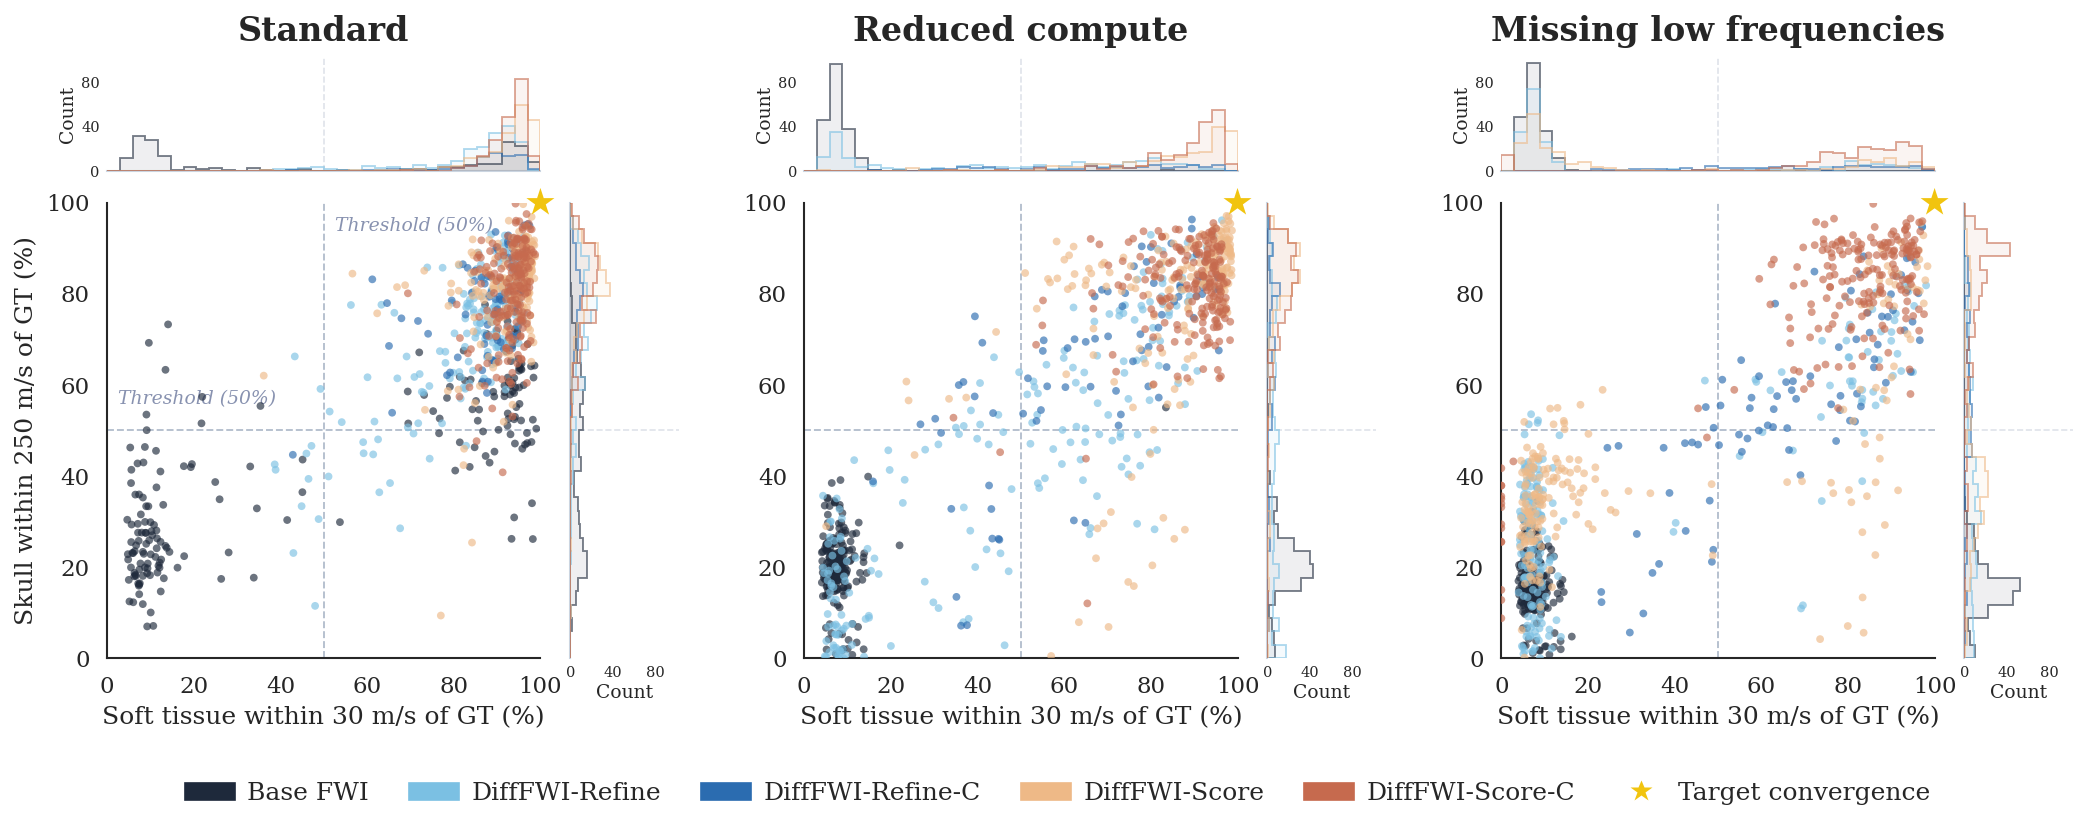

In [8]:
import fig5_convergence

fig5, axes_dict, df5 = fig5_convergence.main(
    show=True,
    use_precomputed=os.path.join(PRECOMPUTED_DIR, "fig5_metrics.csv"),
)

---
## 8. Table: FWI reconstruction performance, full-augmentation prior

In [9]:
TABLE_B3_CAPTION = '\\textbf{FWI reconstruction performance using the full-augmentation diffusion prior.} As \\Cref{tab:fwi_consolidated_metrics}, using the full-augmentation diffusion variant (\\Cref{tab:diffusion_metrics}) as the guidance prior with the convergence criterion defined in \\Cref{sec:reconstruct_eval}. Bold/underline: best/second-best within each scenario block.'

AUG_FULL_OUTPUT_DIR = os.path.join(PAPER_DIR, "results", "aug_full")  # regenerable output only
os.makedirs(AUG_FULL_OUTPUT_DIR, exist_ok=True)

summary_aug = pd.read_csv(os.path.join(PRECOMPUTED_DIR, "summary_main_augfull.csv"))
display(summary_aug)

lt.write_fwi_latex_table(
    os.path.join(PRECOMPUTED_DIR, "summary_main_augfull.csv"),
    os.path.join(AUG_FULL_OUTPUT_DIR, "tableB3_fwi_results_augfull.tex"),
    caption=TABLE_B3_CAPTION,
    label="tab:fwi_augfull",
)

,scenario,method,convergence_rate_pct,tissue_rmse_mean_all,tissue_rmse_std_all,ms_ssim_mean_all,ms_ssim_std_all,psnr_mean_all,psnr_std_all
0,standard,baseline,37.6,59.3,33.9,0.9239,0.0361,20.15,2.30
1,standard,dg,58.4,41.9,33.6,0.9401,0.0327,20.94,2.20
2,standard,dg_c,47.7,52.7,44.8,0.9402,0.0168,21.27,1.18
3,standard,sg,86.8,20.7,14.7,0.9589,0.0351,22.90,1.90
4,standard,sg_c,87.3,33.2,32.3,0.9558,0.0385,23.02,1.87
5,reduced_compute,baseline,0.5,87.4,6.0,0.8942,0.0188,17.95,1.16
6,reduced_compute,dg,2.0,85.4,11.3,0.9060,0.0196,18.45,1.30
7,reduced_compute,dg_c,86.3,20.7,10.8,0.9408,0.0213,20.99,1.43
8,reduced_compute,sg,80.2,27.8,21.2,0.9396,0.0434,21.64,2.18
9,reduced_compute,sg_c,81.7,39.0,18.1,0.9341,0.0355,22.18,1.69


Saved: /cluster/home/fscharitzer/semester-project/diffusion-fwi-2d-clean/paper-results/results/aug_full/tableB3_fwi_results_augfull.tex
